# NeurIPS Diffusion Evaluation

Train diffusion model, compute FID (AE or GyroSwin latent space), evaluate warm restarts, test FID-vs-convergence.

In [ ]:
%load_ext autoreload
%autoreload 2

import sys, os

sys.path.append("..")
os.environ["CUDA_VISIBLE_DEVICES"] = "7"

In [ ]:
import omegaconf, yaml
from collections import defaultdict

import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import pearsonr
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from neugk.diffusion import get_diffusion_runner

from neurips_diff_eval import (
    compute_statistics,
    compute_fid,
    compute_fid_on_latents,
    extract_gyroswin_latents,
    to_model_space,
    from_model_space,
    run_trajectory_pair,
    time_to_convergence,
    plot_correlation_grid,
    load_reference_flux,
)

## 0. Configuration

In [ ]:
DATA_PATH = "/local00/bioinf/galletti/preprocessed_kvikio"
AE_CHECKPOINT = "/restricteddata/ukaea/checkpoints/autoencoders/neurips26/ae_normal/20260328_173023_238/best.pth"
GYROSWIN_CHECKPOINT = "/system/user/publicwork/galletti/checkpoints/gyroswin_large/pytorch_model.bin"
GKW_RAW_DIR = "/restricteddata/ukaea/gyrokinetics/raw"

# pretrained diffusion model
PRETRAINED_DIR = "/system/user/publicwork/galletti/checkpoints/20260408_213033_442"

ID_VAL = [
    "iteration_262.h5",
    "iteration_135.h5",
    "iteration_8.h5",
    "iteration_232.h5",
    "iteration_148.h5",
    "iteration_115.h5",
]
OOD_VAL = [f"ood_iteration_{i}.h5" for i in range(5)]
TRAIN_TRAJS = "iteration_{0-5,7-12,14-31,33-82,84-99}.h5"

N_EPOCHS = 10
BATCH_SIZE = 256
LR = 2e-3
VAL_EVERY = 30
N_DENOISING_STEPS = 10

MINIBATCH_OT = True
NOISE_DISTRIBUTION = "gaussian"  # "gaussian" or "mixture"
CONTINUOUS_TIME = True

FID_MODE = "gyroswin"  # "ae" or "gyroswin"
FID_N_COMPONENTS = 512
FID_MAX_SAMPLES = 128
GEN_BATCH_SIZE = 32

## 1. Train Diffusion Model

In [ ]:
if PRETRAINED_DIR:
    print(f"loading pretrained from {PRETRAINED_DIR}")
    pretrained_cfg = omegaconf.OmegaConf.load(os.path.join(PRETRAINED_DIR, "config.yaml"))
    pretrained_cfg.output_path = PRETRAINED_DIR
    pretrained_cfg.dataset.path = DATA_PATH
    pretrained_cfg.ae_checkpoint = os.path.dirname(AE_CHECKPOINT)  # NOTE: check for isembard models
    pretrained_cfg.dataset.gds_override = True
    pretrained_cfg.dataset.validation_trajectories = ID_VAL
    pretrained_cfg.validation.probe = {"targets": []}
    pretrained_cfg.logging.writer = None
    pretrained_cfg.logging.tqdm = True
    pretrained_cfg.training.num_workers = 0
    pretrained_cfg.training.pin_memory = False
    pretrained_cfg.ddp.enable = False
    pretrained_cfg.deepspeed.enable = False
    runner = get_diffusion_runner(rank=0, cfg=pretrained_cfg, world_size=1)
    ckp = torch.load(
        os.path.join(PRETRAINED_DIR, "best.pth"),
        map_location=runner.device,
        weights_only=False,
    )
    runner.model.load_state_dict(ckp["model_state_dict"])
    print(f"--> loaded diffusion weights from epoch {ckp.get('epoch', '?')}")
else:
    print("training from scratch")
    cfg = omegaconf.OmegaConf.load(os.path.join(os.path.dirname(AE_CHECKPOINT), "config.yaml"))
    with open("dit_config.yaml", "r") as f:
        diff_cfg = omegaconf.DictConfig(yaml.safe_load(f))
    cfg.model = diff_cfg.model
    cfg.ddp = diff_cfg.ddp
    cfg.workflow = "diffusion"
    cfg.output_path = "/tmp/diffusion_eval_pipeline"
    cfg.dataset.path = DATA_PATH
    cfg.dataset.gds_override = False
    cfg.dataset.backend = "gds"
    cfg.ae_checkpoint = os.path.dirname(AE_CHECKPOINT)
    cfg.dataset.training_trajectories = TRAIN_TRAJS
    cfg.dataset.validation_trajectories = ID_VAL
    cfg.model.latent_dim = 512
    cfg.training.batch_size = BATCH_SIZE
    cfg.training.learning_rate = LR
    cfg.training.n_epochs = N_EPOCHS
    cfg.validation.validate_every_n_epochs = VAL_EVERY
    cfg.validation.probe = {"targets": []}
    cfg.logging.writer = None
    cfg.logging.tqdm = True
    cfg.training.num_workers = 0
    cfg.training.pin_memory = False
    cfg.model.diffusion.minibatch_ot = MINIBATCH_OT
    cfg.model.diffusion.noise_distribution = NOISE_DISTRIBUTION
    cfg.model.diffusion.continuous_time = CONTINUOUS_TIME
    # cfg.dataset.normalization = {
    #     "df": {"type": "zscore", "agg_axes": [0, 1, 3, 4, 5]},
    #     "flux": {"type": "zscore", "agg_axes": None},
    #     "phi": {"type": "zscore", "agg_axes": [0, 1, 2]},
    # }
    cfg.ddp.enable = False
    cfg.deepspeed.enable = False
    runner = get_diffusion_runner(rank=0, cfg=cfg, world_size=1)

print(f"Model: {sum(p.numel() for p in runner.model.parameters())/1e6:.1f}M params")
print(f"Train: {len(runner.trainset)}, Val: {sum(len(v) for v in runner.valsets)}")

loading pretrained from /system/user/publicwork/galletti/checkpoints/20260408_213033_442
Diffusion latent dataset mode: AE
Loaded AE config for normalization from /restricteddata/ukaea/checkpoints/autoencoders/neurips26/ae_normal/20260328_173023_238/config.yaml
Loading ['df', 'phi', 'flux'] in dataset
    metadata: 289 files in 0.1s (lightweight=True)
loading aggregated stats from /local00/bioinf/galletti/preprocessed_kvikio/diff_df_flux_phi_offset80_mu_57f5caf2_df01345_phi012_agg_stats.pkl
    metadata: 6 files in 0.0s (lightweight=True)
Train: 44400
Holdout trajectories (val): 108
Validation ratio: 0.00
[init] RSS after setup_data: 1.3 GB


/system/apps/userenv/galletti/mhd/bin/../lib/gcc/x86_64-conda-linux-gnu/11.2.0/../../../../x86_64-conda-linux-gnu/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/system/apps/userenv/galletti/mhd/bin/../lib/gcc/x86_64-conda-linux-gnu/11.2.0/../../../../x86_64-conda-linux-gnu/bin/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


AE parameters: 225.8M
Compression: 604.4x (type: ae). (32, *[32, 16, 85, 32]) -> (256, *[4, 2, 9, 4])
Loading model /restricteddata/ukaea/checkpoints/autoencoders/neurips26/ae_normal/20260328_173023_238/best.pth (stopped at epoch 400) 
loading precomputed latents from /local00/bioinf/galletti/preprocessed_kvikio/diff_train_latents_offset80_mu_57f5caf20c1e_latents_ae238.pkl
latent mean: 0.1904270499944687
latent var: 35.83047866821289
latent l2 norm: 1625.883056640625
latent stats -> mean(var): 3.583048e+01, latent_scale: 0.167060
Parameters: 120.5M
[init] RSS after setup_components: 34.3 GB
--> loaded diffusion weights from epoch 200
Model: 120.5M params
Train: 44400, Val: 108


In [ ]:
raw = runner.trainset.__getitem__(100, get_normalized=False, override_latens=True)
print(f"raw std: {raw.df.std():.4f}, raw mean: {raw.df.mean():.4f}")
scale, shift = runner.trainset._get_scale_shift(0, "df", raw.df)
print(f"shift shape: {shift.shape}, scale shape: {scale.shape}")
print(f"shift: {shift.squeeze()}")
print(f"scale: {scale.squeeze()}")
manual = (raw.df - shift) / scale
print(f"manual normalized std: {manual.std():.4f}")

raw std: 2.3217, raw mean: 0.0109
shift shape: torch.Size([1, 1, 8, 1, 1, 1]), scale shape: torch.Size([1, 1, 8, 1, 1, 1])
shift: tensor([-1.8142e-03, -8.1099e-04,  9.5510e-05,  3.4094e-04,  1.4580e-04,
         3.3951e-05,  1.3060e-05,  1.4045e-06])
scale: tensor([3.9545, 2.6090, 0.9670, 0.3254, 0.3198, 0.1634, 0.0528, 0.0114])
manual normalized std: 1.3245


Input shape: torch.Size([4, 32, 8, 16, 85, 32]), Recon shape: torch.Size([4, 32, 8, 16, 85, 32])
AE recon MSE: 0.332995
AE recon rel err: 0.4357


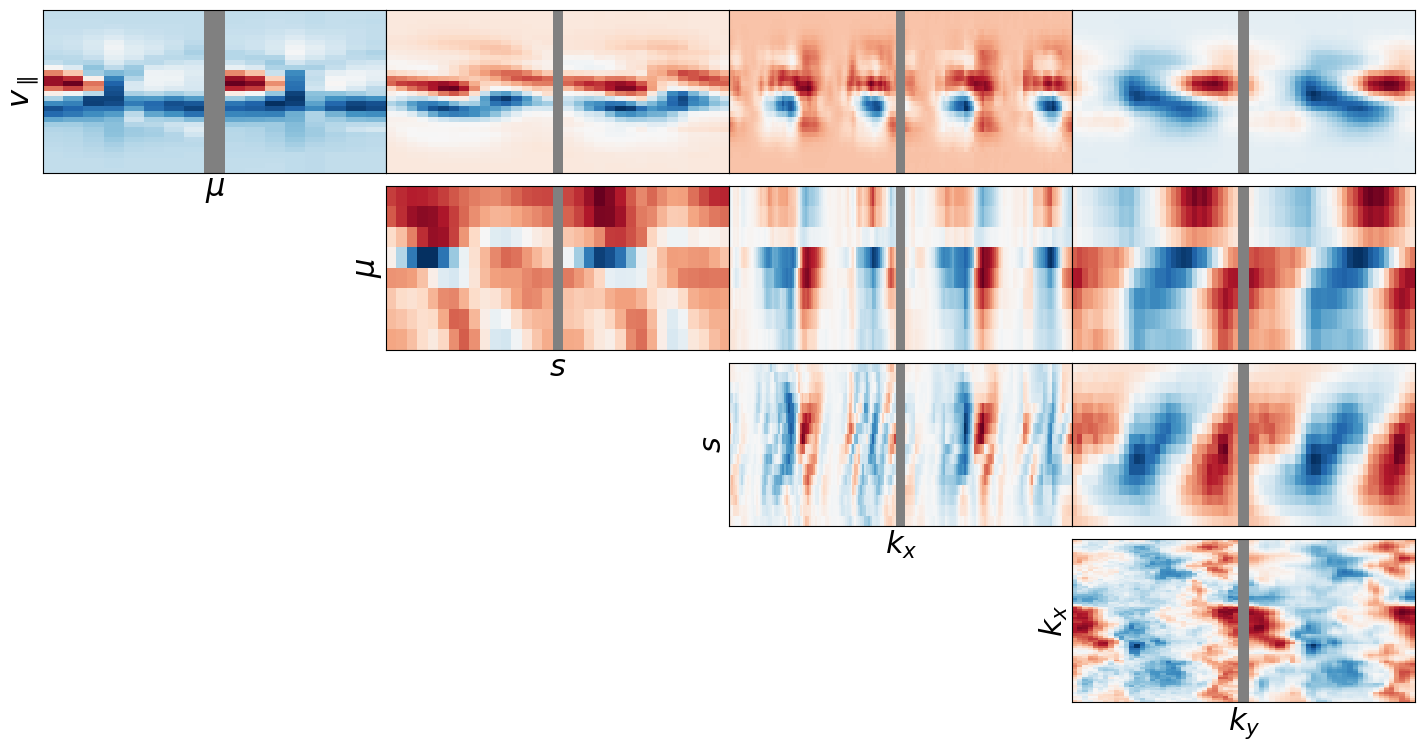

In [ ]:
from neugk.plot_utils import plot_nd

sample = runner.trainset.__getitem__(100, get_normalized=True, override_latens=True)
df_in = sample.df.unsqueeze(0).to(runner.device)
cond = sample.conditioning.unsqueeze(0).to(runner.device)

ae = runner.autoencoder
ae.eval()
with torch.no_grad():
    recon = ae(df_in, condition=cond)["df"]

df_gt = df_in[0].cpu()
df_rec = recon[0].cpu()

print(f"Input shape: {df_gt.shape}, Recon shape: {df_rec.shape}")
print(f"AE recon MSE: {(df_gt - df_rec).pow(2).mean():.6f}")
print(f"AE recon rel err: {(df_gt - df_rec).norm() / df_gt.norm():.4f}")

_ = plot_nd(df_gt, df_rec, to_wandb=False)

In [ ]:
if not PRETRAINED_DIR:
    logs = runner(skip_eval=True)
else:
    logs = [{}]

In [ ]:
for k, v in logs[-1].items():
    if "info/" in str(k):
        print(f"  {k}: {v:.1f}")

GT shape: torch.Size([4, 32, 8, 16, 85, 32]), Gen shape: torch.Size([4, 32, 8, 16, 85, 32])
Gen vs GT rel err: 1.2657


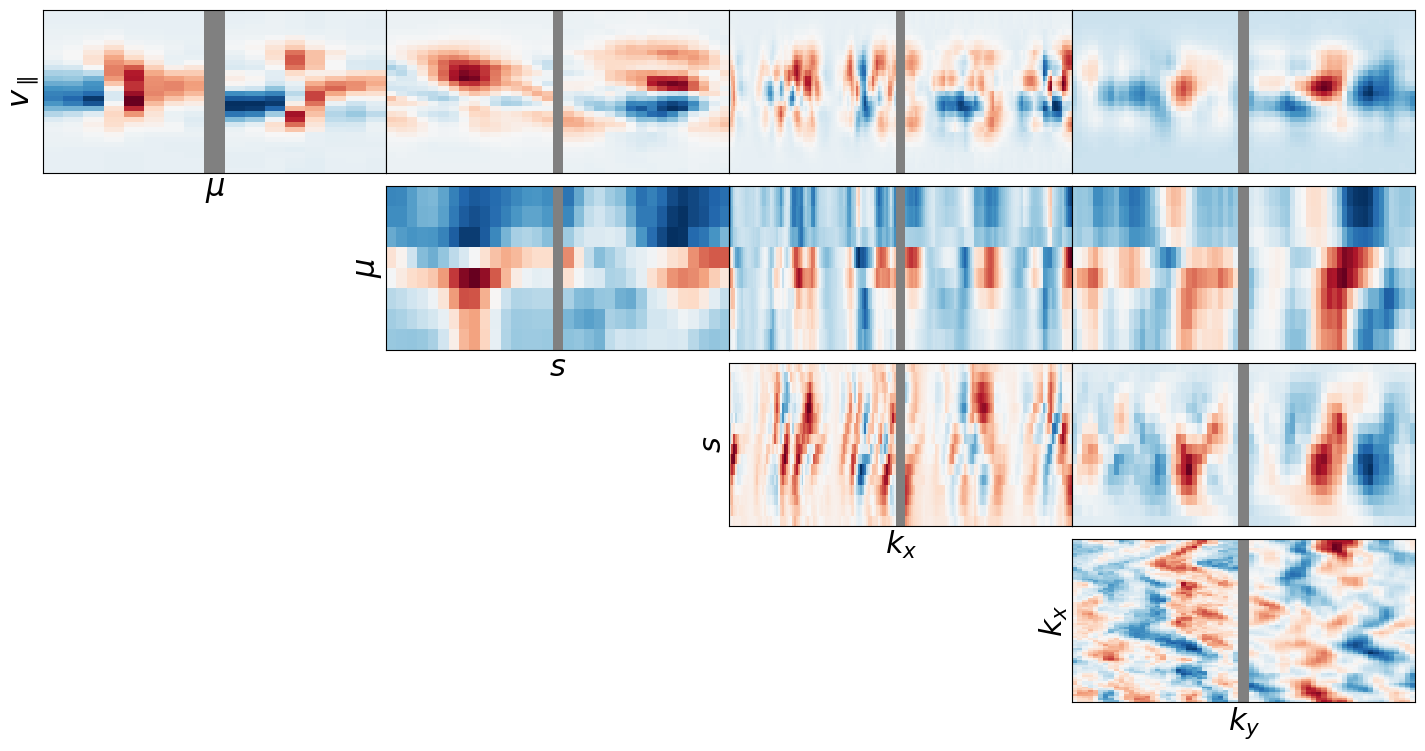

In [ ]:
sample = runner.trainset.__getitem__(0, get_normalized=True, override_latens=True)
cond = sample.conditioning.unsqueeze(0).to(runner.device)

runner.model.eval()
with torch.no_grad():
    gen_out = runner.sample(cond, latent_only=False, steps=N_DENOISING_STEPS)

df_gt = sample.df.cpu()
df_gen = gen_out["df"][0].cpu()

print(f"GT shape: {df_gt.shape}, Gen shape: {df_gen.shape}")
print(f"Gen vs GT rel err: {(df_gt - df_gen).norm() / df_gt.norm():.4f}")

_ = plot_nd(df_gt, df_gen, to_wandb=False)

In [ ]:
# epochs = [l["epoch"] for l in logs]
# train_loss = [l.get("train/loss", l.get("train/df", np.nan)) for l in logs]
# val_epochs = [l["epoch"] for l in logs if "val_traj/avg_flux_rmse" in l]
# val_rmse = [l["val_traj/avg_flux_rmse"] for l in logs if "val_traj/avg_flux_rmse" in l]

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# ax1.plot(epochs, train_loss, lw=1)
# ax1.set(xlabel="Epoch", ylabel="Loss", title="Training loss")
# ax1.grid(True, alpha=0.15)
# if val_rmse:
#     ax2.plot(val_epochs, val_rmse, "o-", markersize=4)
# ax2.set(xlabel="Epoch", ylabel="Avg flux RMSE", title="Validation")
# ax2.grid(True, alpha=0.15)
# fig.tight_layout()

# for l in reversed(logs):
#     if "val_plots" in l:
#         for name, obj in l["val_plots"].items():
#             if hasattr(obj, "savefig"): display(obj)
#         break

## 1.5 Flux UQ (ID)

In [ ]:
runner.model.eval()
log_metrics, val_plots, _ = runner.evaluate(epoch=0, evaluate_probing=False, no_save=True)

validation holdout trajectories: 100%|██████████| 2/2 [00:32<00:00, 16.25s/it]


In [ ]:
val_plots.keys()

dict_keys(['df (T=97.20, Random draw)', 'phi (T=97.20, Random draw)', 'avg_flux_UQ'])

  val_traj/avg_flux_rmse: 23.9256
  val_traj/complex_mse: 23.8954
  val_traj/complex_ssim: 0.4747
  val_traj/flux_int: 3694.8528
  val_traj/phi_int: 18890.1465


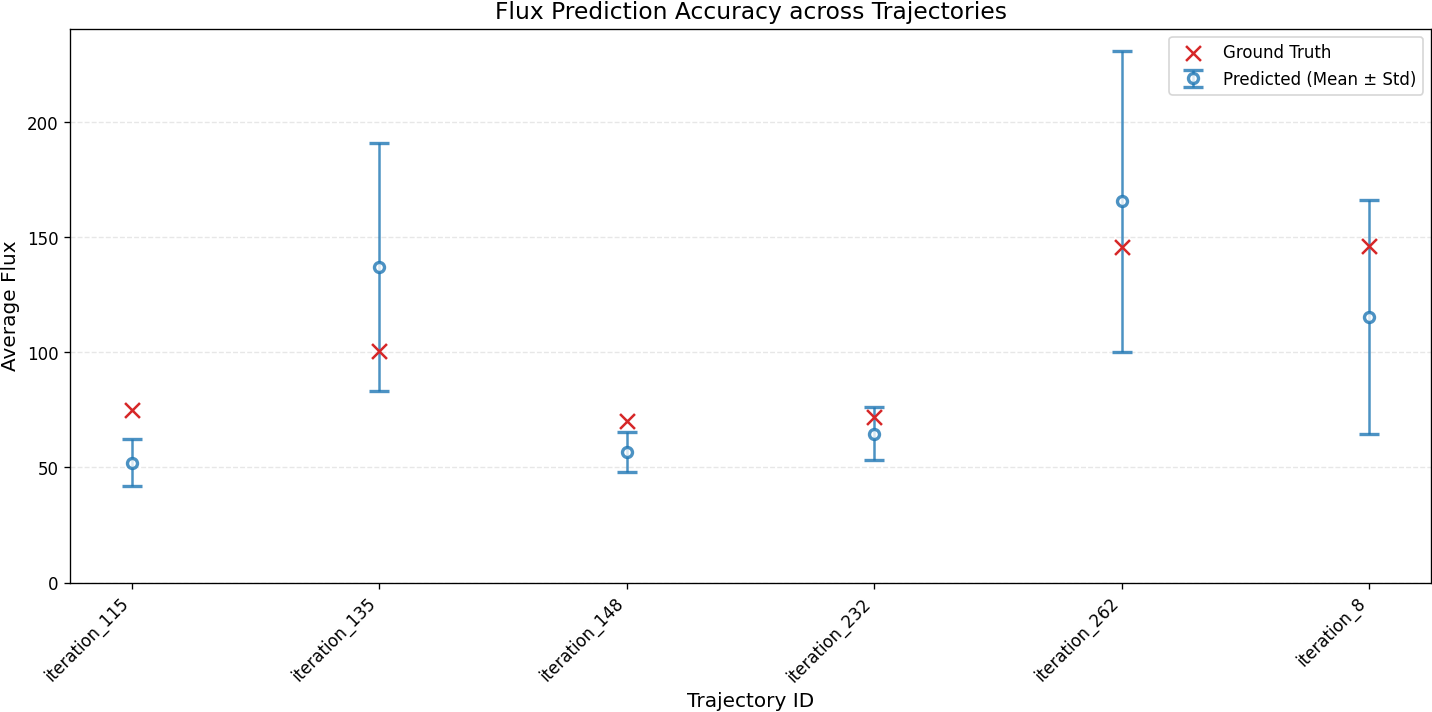

In [ ]:
for k, v in sorted(log_metrics.items()):
    print(f"  {k}: {v:.4f}")

display(val_plots["avg_flux_UQ"].image)

training set: 44400 samples, latent dim=73728
subsampled to 256 samples


generating latents: 100%|██████████| 8/8 [00:03<00:00,  2.43it/s]


fitting PCA (32 components)...
fitting ridge probes...
PCA: 73728 -> 32 (46.4% var)
flux probe — RMSE ae: 20.0718, RMSE gen: 29.2543
  dg — RMSE ae: 1.1419, RMSE gen: 1.1181
  itg — RMSE ae: 1.3661, RMSE gen: 1.3410
  q — RMSE ae: 1.3890, RMSE gen: 1.3909
  s_hat — RMSE ae: 0.6102, RMSE gen: 0.6036
loading 6 val trajectories...
  collected 12 samples


generating latents: 100%|██████████| 1/1 [00:00<00:00,  5.18it/s]


flux probe (val) — RMSE ae: 40.2178, RMSE gen: 29.5773


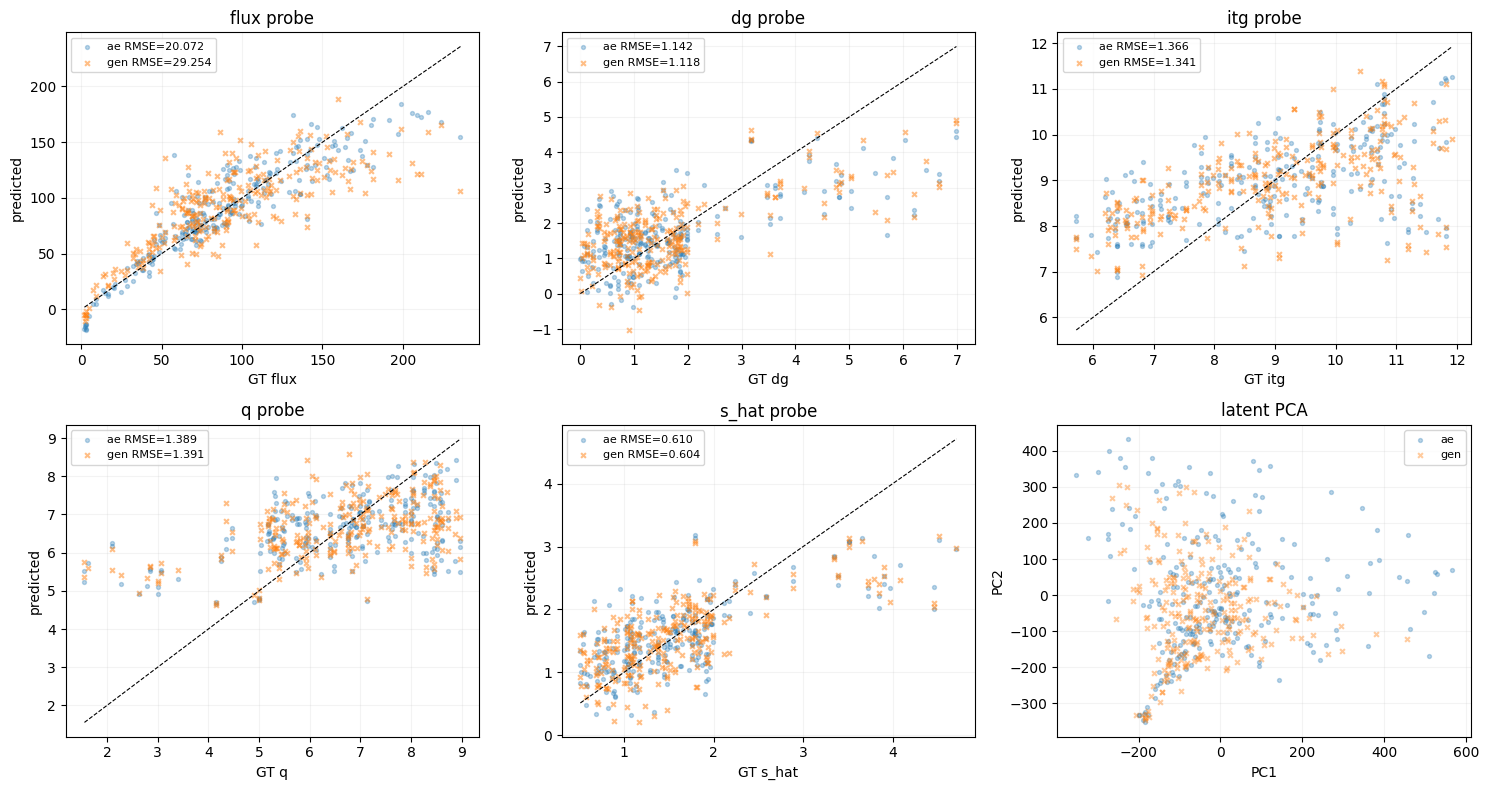

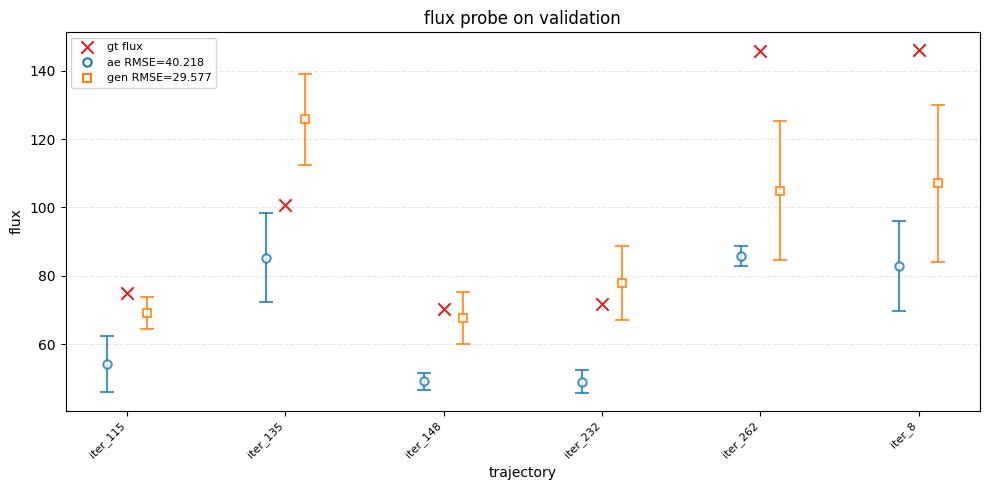

In [ ]:
from neurips_diff_eval import (
    collect_latents,
    generate_latents,
    fit_probes,
    plot_probes,
    encode_valset,
    plot_val_probe,
)

PROBE_N_COMPONENTS = 64
PROBE_ALPHA = 1.0
PROBE_SUBSAMPLE = 256

_cond_keys = sorted(runner.cfg.model.conditioning)
X_ae, y_flux, C_train = collect_latents(runner.trainset.precomputed_latents, _cond_keys)
print(f"training set: {X_ae.shape[0]} samples, latent dim={X_ae.shape[1]}")

if PROBE_SUBSAMPLE and PROBE_SUBSAMPLE < len(X_ae):
    idx = np.random.choice(len(X_ae), PROBE_SUBSAMPLE, replace=False)
    X_ae, y_flux, C_train = X_ae[idx], y_flux[idx], C_train[idx]
    print(f"subsampled to {PROBE_SUBSAMPLE} samples")

X_gen = generate_latents(runner, C_train, batch_size=GEN_BATCH_SIZE, steps=N_DENOISING_STEPS)

probes = fit_probes(
    X_ae,
    X_gen,
    y_flux,
    _cond_keys,
    C_train,
    n_components=PROBE_N_COMPONENTS,
    alpha=PROBE_ALPHA,
)
print(
    f"PCA: {X_ae.shape[1]} -> {probes['pca'].n_components_} ({probes['pca'].explained_variance_ratio_.sum():.1%} var)"
)
print(f"flux probe — RMSE ae: {probes['flux']['rmse_ae']:.4f}, RMSE gen: {probes['flux']['rmse_gen']:.4f}")
for k in _cond_keys:
    print(f"  {k} — RMSE ae: {probes['cond']['rmse'][k]['ae']:.4f}, RMSE gen: {probes['cond']['rmse'][k]['gen']:.4f}")

_ = plot_probes(y_flux, probes, _cond_keys, C_train, X_ae, X_gen)

X_val_ae, C_val, y_val_gt, val_fi = encode_valset(
    runner.valsets[0],
    runner.autoencoder,
    _cond_keys,
    runner.device,
    batch_size=GEN_BATCH_SIZE,
)
X_val_gen = generate_latents(runner, C_val, batch_size=GEN_BATCH_SIZE, steps=N_DENOISING_STEPS)

pca = probes["pca"]
pred_val_ae = probes["flux"]["probe_ae"].predict(pca.transform(X_val_ae))
pred_val_gen = probes["flux"]["probe_gen"].predict(pca.transform(X_val_gen))
rmse_val_ae = np.sqrt(((y_val_gt - pred_val_ae) ** 2).mean())
rmse_val_gen = np.sqrt(((y_val_gt - pred_val_gen) ** 2).mean())
print(f"flux probe (val) — RMSE ae: {rmse_val_ae:.4f}, RMSE gen: {rmse_val_gen:.4f}")

_ = plot_val_probe(
    runner.valsets[0],
    pred_val_ae,
    pred_val_gen,
    y_val_gt,
    val_fi,
    rmse_val_ae,
    rmse_val_gen,
)

## 2. FID Evaluation

- **`ae`**: FID in AE bottleneck (fast, no decode)
- **`gyroswin`**: FID using frozen GyroSwin encoder (Inception-FID analog)

In [ ]:
if FID_MODE == "gyroswin":
    from gyroswin_legacy import load_gyroswin_large

    gyroswin_model = load_gyroswin_large(GYROSWIN_CHECKPOINT, device=runner.device)
    feature_fn = lambda b, device, **kw: extract_gyroswin_latents(gyroswin_model, b, device, **kw)
    fid_label = "GyroSwin-FID"
else:
    feature_fn = None
    fid_label = "AE-FID"
print(f"Mode: {fid_label}")

/system/user/galletti/git/quasilinear_magic/models/nd_vit/positional.py:94: UserWarning: Sincos initialization only works if len(grid_size) < dim(returns zero padding otherwise). Switching to random
  warn(


GyroSwin-Large: 998.3M params
Mode: GyroSwin-FID


  iter_148: 16 snapshots
  iter_232: 16 snapshots
  iter_135: 16 snapshots
  iter_115: 16 snapshots
  iter_8: 16 snapshots
  iter_262: 16 snapshots


extracting gyroswin features: 100%|██████████| 3/3 [00:04<00:00,  1.41s/it]


PCA: 589824 -> 96 (100.0% var)


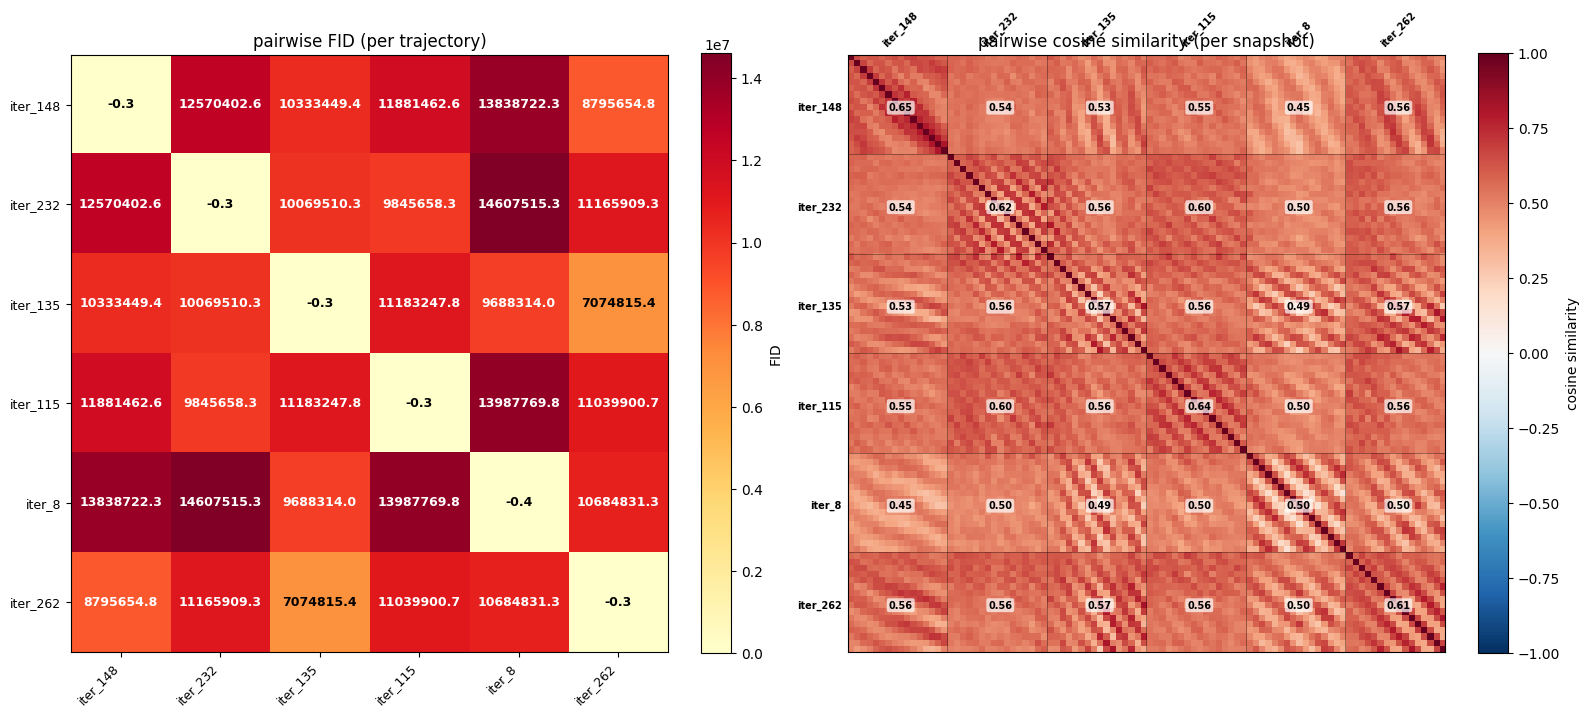

In [ ]:
valset = runner.valsets[0]
t_start, t_step, n_snap = 80, 5, 32

_cond_meta_map_fid = {"itg": "ion_temp_grad", "dg": "density_grad"}
_cond_keys_fid = sorted(runner.cfg.model.conditioning)
flat_idx_map = {(f, t): idx for idx, (f, t) in valset.flat_index_to_file_and_tstep.items()}

import re as _re

all_dfs, all_conds, all_traj_idx, all_snap_labels = [], [], [], []
traj_labels = []

for fi in range(len(valset.files)):
    meta = valset.metadata[fi]
    fpath = valset.files[fi]
    m = _re.search(r"iteration_(\d+)", fpath)
    label = f"iter_{m.group(1)}" if m else f"f{fi}"

    cond_vals = [float(np.squeeze(meta[_cond_meta_map_fid.get(k, k)])) for k in _cond_keys_fid]

    snap_indices = [t_start + j * t_step for j in range(n_snap)]
    n_ts = len(meta["timesteps"])
    snap_indices = [s for s in snap_indices if s < n_ts]

    count = 0
    for si in snap_indices:
        t_idx = si - valset.offsets[fi]
        if t_idx < 0 or (fi, t_idx) not in flat_idx_map:
            continue
        sample = valset[flat_idx_map[(fi, t_idx)]]
        if sample.df is None:
            continue
        all_dfs.append(sample.df)
        all_conds.append(torch.tensor(cond_vals + [float(meta["timesteps"][si])], dtype=torch.float32))
        all_traj_idx.append(len(traj_labels))
        all_snap_labels.append(f"{label}:{si}")
        count += 1

    if count >= 2:
        traj_labels.append(label)
        print(f"  {label}: {count} snapshots")
    else:
        for _ in range(count):
            all_dfs.pop(); all_conds.pop(); all_traj_idx.pop(); all_snap_labels.pop()

all_feats = []
for i in tqdm(range(0, len(all_dfs), GEN_BATCH_SIZE), desc="extracting gyroswin features"):
    batch_df = torch.stack(all_dfs[i:i+GEN_BATCH_SIZE])
    batch_cond = torch.stack(all_conds[i:i+GEN_BATCH_SIZE])
    all_feats.append(extract_gyroswin_latents(gyroswin_model, batch_df, device=runner.device, condition=batch_cond))
all_feats = np.concatenate(all_feats)
all_traj_idx = np.array(all_traj_idx)

traj_feats = {}
for ti, label in enumerate(traj_labels):
    traj_feats[label] = all_feats[all_traj_idx == ti]

n_traj = len(traj_labels)
n_total = len(all_feats)

from sklearn.decomposition import PCA
n_comp = min(FID_N_COMPONENTS, all_feats.shape[0], all_feats.shape[1])
pca_fid = PCA(n_components=n_comp).fit(all_feats)
traj_feats_pca = {l: pca_fid.transform(traj_feats[l]) for l in traj_labels}
print(f"PCA: {all_feats.shape[1]} -> {n_comp} ({pca_fid.explained_variance_ratio_.sum():.1%} var)")

fid_matrix = np.full((n_traj, n_traj), np.nan)
traj_stats = {i: compute_statistics(traj_feats_pca[li]) for i, li in enumerate(traj_labels)}
for i in range(n_traj):
    for j in range(i, n_traj):
        fid_val = compute_fid(*traj_stats[i], *traj_stats[j])
        fid_matrix[i, j] = fid_val
        fid_matrix[j, i] = fid_val

feats_norm = all_feats / (np.linalg.norm(all_feats, axis=1, keepdims=True) + 1e-8)
cos_matrix = feats_norm @ feats_norm.T

traj_boundaries = []
cur = 0
for li in traj_labels:
    n = len(traj_feats[li])
    traj_boundaries.append((cur, cur + n, li))
    cur += n

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

vmax = np.nanmax(fid_matrix[~np.eye(n_traj, dtype=bool)]) if n_traj > 1 else 1.0
im0 = axes[0].imshow(fid_matrix, cmap="YlOrRd", vmin=0, vmax=vmax)
axes[0].set_xticks(range(n_traj))
axes[0].set_xticklabels(traj_labels, rotation=45, ha="right", fontsize=9)
axes[0].set_yticks(range(n_traj))
axes[0].set_yticklabels(traj_labels, fontsize=9)
for i in range(n_traj):
    for j in range(n_traj):
        if np.isfinite(fid_matrix[i, j]):
            axes[0].text(j, i, f"{fid_matrix[i,j]:.1f}", ha="center", va="center",
                         fontsize=9, fontweight="bold",
                         color="white" if fid_matrix[i, j] > 0.6 * vmax else "black")
plt.colorbar(im0, ax=axes[0], label="FID", fraction=0.046)
axes[0].set_title("pairwise FID (per trajectory)")

im1 = axes[1].imshow(cos_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
for si, (s1, e1, l1) in enumerate(traj_boundaries):
    axes[1].axhline(s1 - 0.5, color="k", lw=0.5, alpha=0.5)
    axes[1].axvline(s1 - 0.5, color="k", lw=0.5, alpha=0.5)
    mid1 = (s1 + e1) / 2
    axes[1].text(-1.5, mid1, l1, ha="right", va="center", fontsize=7, fontweight="bold")
    axes[1].text(mid1, -1.5, l1, ha="center", va="bottom", fontsize=7, fontweight="bold", rotation=45)
    for sj, (s2, e2, l2) in enumerate(traj_boundaries):
        block_mean = cos_matrix[s1:e1, s2:e2].mean()
        axes[1].text((s2 + e2) / 2, mid1, f"{block_mean:.2f}",
                     ha="center", va="center", fontsize=7, fontweight="bold",
                     color="black", bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))
axes[1].axhline(cur - 0.5, color="k", lw=0.5, alpha=0.5)
axes[1].axvline(cur - 0.5, color="k", lw=0.5, alpha=0.5)
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.colorbar(im1, ax=axes[1], label="cosine similarity", fraction=0.046)
axes[1].set_title("pairwise cosine similarity (per snapshot)")

fig.tight_layout()

In [ ]:
runner.model.eval()

if FID_MODE == "ae":
    real_lats, real_conds = [], []
    for (fi, ti), s in tqdm(runner.trainset.precomputed_latents.items(), desc="Real latents"):
        real_lats.append(np.array(s["x"]).reshape(-1))
        real_conds.append(np.array([s["itg"], s["dg"], s["s_hat"], s["q"]]))
        if FID_MAX_SAMPLES and len(real_lats) >= FID_MAX_SAMPLES:
            break
    X_real, C_real = np.stack(real_lats), np.stack(real_conds)
    idx = np.random.choice(len(X_real), len(X_real), replace=True)
    gen_lats = []
    for i in tqdm(range(0, len(X_real), GEN_BATCH_SIZE), desc="Gen latents"):
        c = torch.tensor(
            C_real[idx[i : i + GEN_BATCH_SIZE]],
            dtype=torch.float32,
            device=runner.device,
        )
        with torch.no_grad():
            z = runner.sample(c, latent_only=True, steps=N_DENOISING_STEPS)
            gen_lats.append(z.cpu().numpy().reshape(z.shape[0], -1))
    X_gen = np.concatenate(gen_lats)

elif FID_MODE == "gyroswin":
    n = min(FID_MAX_SAMPLES or 512, len(runner.valsets[0]))
    real_s = [runner.valsets[0][i].df for i in tqdm(range(n), desc="Loading real")]
    gen_s, gen_conds_list = [], []
    _cond_meta_map = {"itg": "ion_temp_grad", "dg": "density_grad"}
    _cond_keys = sorted(runner.cfg.model.conditioning)
    real_conds_list = []
    for idx in range(n):
        fi, _ = runner.valsets[0].flat_index_to_file_and_tstep[idx]
        meta = runner.valsets[0].metadata[fi]
        real_conds_list.append(
            torch.tensor(
                [float(np.squeeze(meta[_cond_meta_map.get(k, k)])) for k in _cond_keys],
                dtype=torch.float32,
            )
        )
    conds = torch.stack(real_conds_list)
    for i in tqdm(range(0, n, GEN_BATCH_SIZE), desc="Generating"):
        c = conds[i : i + GEN_BATCH_SIZE].to(runner.device)
        with torch.no_grad():
            p = runner.sample(c, steps=N_DENOISING_STEPS, latent_only=False)
            for j in range(p["df"].shape[0]):
                gen_s.append(p["df"][j].cpu())
                gen_conds_list.append(conds[i + j])
    print(f"Extracting features...")
    _, X_real, X_gen = compute_fid_on_latents(
        real_s,
        gen_s,
        feature_fn,
        device=runner.device,
        n_components=FID_N_COMPONENTS,
        real_conditions=real_conds_list,
        gen_conditions=gen_conds_list,
    )

print(f"Real: {X_real.shape}, Gen: {X_gen.shape}")

Generating: 100%|██████████| 4/4 [00:07<00:00,  1.83s/it]


Extracting features...
Real: (108, 108), Gen: (108, 108)


In [ ]:
X_rf, X_gf = X_real, X_gen
if FID_N_COMPONENTS and FID_N_COMPONENTS < X_real.shape[1]:
    pca = PCA(n_components=FID_N_COMPONENTS)
    X_rf = pca.fit_transform(X_real)
    X_gf = pca.transform(X_gen)
    print(f"PCA: {X_real.shape[1]}->{FID_N_COMPONENTS} ({pca.explained_variance_ratio_.sum():.1%} var)")

mu_r, sig_r = compute_statistics(X_rf)
mu_g, sig_g = compute_statistics(X_gf)
fid_global = compute_fid(mu_r, sig_r, mu_g, sig_g)
print(f"Global {fid_label}: {fid_global:.4f}")

Global GyroSwin-FID: 2357426.4587


In [ ]:
per_traj_fids = {}
if FID_MODE == "ae":
    ptr = defaultdict(list)
    for (fi, ti), s in runner.trainset.precomputed_latents.items():
        ptr[fi].append(np.array(s["x"]).reshape(-1))
    for fi, rl in tqdm(ptr.items(), desc="Per-traj FID"):
        Xt = np.stack(rl)
        if len(Xt) < 10:
            continue
        sk = next(k for k in runner.trainset.precomputed_latents if k[0] == fi)
        s = runner.trainset.precomputed_latents[sk]
        c = torch.tensor(
            [[s["itg"], s["dg"], s["s_hat"], s["q"]]],
            dtype=torch.float32,
            device=runner.device,
        ).expand(len(Xt), -1)
        with torch.no_grad():
            zg = runner.sample(c, latent_only=True, steps=N_DENOISING_STEPS)
            Xg = zg.cpu().numpy().reshape(zg.shape[0], -1)
        if FID_N_COMPONENTS and FID_N_COMPONENTS < Xt.shape[1]:
            Xt, Xg = pca.transform(Xt), pca.transform(Xg)
        m1, s1 = compute_statistics(Xt)
        m2, s2 = compute_statistics(Xg)
        per_traj_fids[fi] = compute_fid(m1, s1, m2, s2)
    print(f"Per-traj mean: {np.mean(list(per_traj_fids.values())):.4f}")

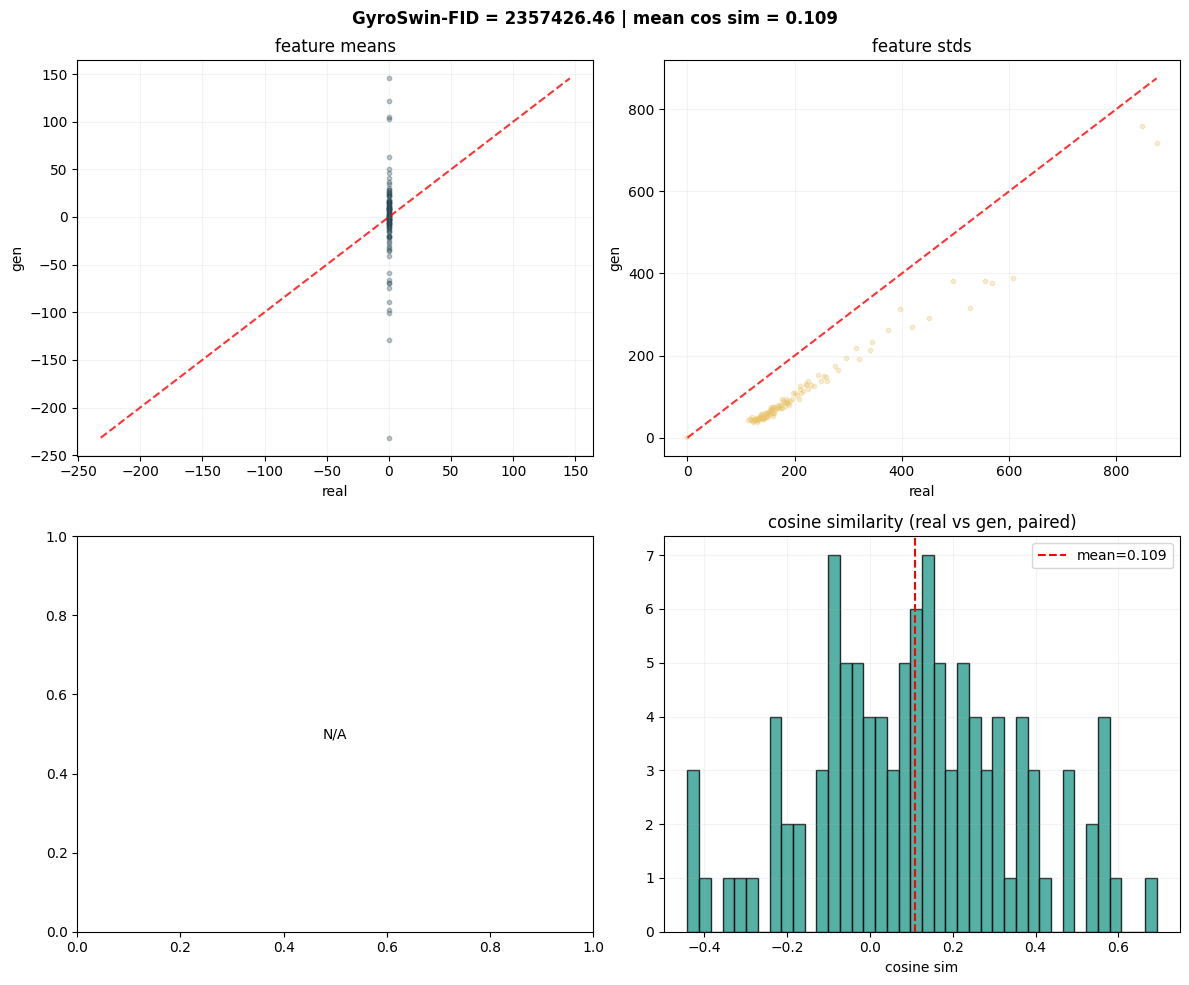

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

mr, mg = X_real.mean(0), X_gen.mean(0)
axes[0, 0].scatter(mr, mg, alpha=0.3, s=10, color="#264653")
lim = [min(mr.min(), mg.min()), max(mr.max(), mg.max())]
axes[0, 0].plot(lim, lim, "r--", alpha=0.8)
axes[0, 0].set(title="feature means", xlabel="real", ylabel="gen")
axes[0, 0].grid(True, alpha=0.15)

sr, sg = X_real.std(0), X_gen.std(0)
axes[0, 1].scatter(sr, sg, alpha=0.3, s=10, color="#e9c46a")
lim = [min(sr.min(), sg.min()), max(sr.max(), sg.max())]
axes[0, 1].plot(lim, lim, "r--", alpha=0.8)
axes[0, 1].set(title="feature stds", xlabel="real", ylabel="gen")
axes[0, 1].grid(True, alpha=0.15)

if per_traj_fids:
    axes[1, 0].hist(list(per_traj_fids.values()), bins=30, color="#2a9d8f", edgecolor="k", alpha=0.8)
    axes[1, 0].axvline(fid_global, color="red", ls="--", lw=1.5, label=f"global={fid_global:.1f}")
    axes[1, 0].set(title=f"per-traj {fid_label}", xlabel="FID")
    axes[1, 0].legend()
else:
    axes[1, 0].text(0.5, 0.5, "N/A", ha="center", va="center", transform=axes[1, 0].transAxes)

real_norm = X_real / (np.linalg.norm(X_real, axis=1, keepdims=True) + 1e-8)
gen_norm = X_gen / (np.linalg.norm(X_gen, axis=1, keepdims=True) + 1e-8)
cos_per_sample = np.sum(real_norm * gen_norm, axis=1)
axes[1, 1].hist(cos_per_sample, bins=40, color="#2a9d8f", edgecolor="k", alpha=0.8)
axes[1, 1].axvline(cos_per_sample.mean(), color="red", ls="--", lw=1.5,
                    label=f"mean={cos_per_sample.mean():.3f}")
axes[1, 1].set(title="cosine similarity (real vs gen, paired)", xlabel="cosine sim")
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.15)

fig.suptitle(f"{fid_label} = {fid_global:.2f} | mean cos sim = {cos_per_sample.mean():.3f}", fontweight="bold")
fig.tight_layout()

## 3. Warm Restart Evaluation

In [ ]:
from gyaradax import gk_from_gkw_dir

In [ ]:
N_EVAL_STEPS = 1000
WARM_RESTART_ITERATIONS = [13]

warm_results = {}
_cond_keys = sorted(runner.cfg.model.conditioning)

for iteration in WARM_RESTART_ITERATIONS:
    print(f"\n{'=' * 88}\nIteration {iteration}\n{'=' * 88}")
    df_gt, geometry, params, state_init, pre = gk_from_gkw_dir(
        os.path.join(GKW_RAW_DIR, f"iteration_{iteration}"),
        mixed_precision=True,
        k_index=80,
    )

    _param_map = {"itg": "rlt", "dg": "rln", "s_hat": "shat", "q": "q"}
    cond = torch.tensor(
        [[float(getattr(params, _param_map[k])) for k in _cond_keys]],
        dtype=torch.float32,
        device=runner.device,
    )

    matching = [f for f in runner.trainset.files if f"iteration_{iteration}" in f]
    fi = runner.trainset.files.index(matching[0]) if matching else -1

    with torch.no_grad():
        DF_PRED = runner.sample(cond, latent_only=False, steps=N_DENOISING_STEPS)["df"][0].cpu().numpy()

    df_warm = from_model_space(DF_PRED)
    log_gt, log_warm = run_trajectory_pair(
        df_gt,
        df_warm,
        geometry,
        params,
        pre,
        state_init,
        N_EVAL_STEPS,
        f"iter-{iteration}",
        chunk_size=10,
        backend="jax",
        print_every=100,
    )
    ref_mean, ref_std = load_reference_flux(GKW_RAW_DIR, iteration)
    print(f"  Reference flux: mean={ref_mean:.3e}, std={ref_std:.3e}")
    ttc = time_to_convergence(log_warm, log_gt, log_gt["time"], ref_flux_mean=ref_mean, ref_flux_std=ref_std)
    ttc_flux, ttc_spec = ttc["flux"], ttc["ky_spec"]
    fid_val = per_traj_fids.get(fi, fid_global if "fid_global" in dir() else np.nan)

    warm_results[iteration] = dict(
        fid=fid_val,
        ttc_flux=ttc_flux,
        ttc_spec=ttc_spec,
        log_gt=log_gt,
        log_warm=log_warm,
        df_pred=DF_PRED,
    )
    print(f"  TTC_flux={ttc_flux:.3f}, TTC_spec={ttc_spec:.3f}, FID={fid_val:.4f}")


Iteration 13


cuBLAS < 13.2 (120804 found) has a known issue where many kernels free TMEM buffers multiple times. Executing a cuBLAS kernel concurrently with another kernel (e.g. on another stream) can lead to silent data corruption.


  [iter-13] 100/1000  t=98.200  Q_gt=6.3396e+01  Q_warm=5.9398e+01  r(ky)=0.961
  [iter-13] 200/1000  t=99.200  Q_gt=6.5157e+01  Q_warm=4.6080e+01  r(ky)=0.919
  [iter-13] 300/1000  t=100.200  Q_gt=6.4577e+01  Q_warm=2.1976e+01  r(ky)=0.942
  [iter-13] 400/1000  t=101.200  Q_gt=5.9980e+01  Q_warm=1.8437e+01  r(ky)=0.927
  [iter-13] 500/1000  t=102.200  Q_gt=5.6520e+01  Q_warm=1.6849e+01  r(ky)=0.946
  [iter-13] 600/1000  t=103.200  Q_gt=5.6036e+01  Q_warm=2.0460e+01  r(ky)=0.918
  [iter-13] 700/1000  t=104.200  Q_gt=5.5211e+01  Q_warm=1.8140e+01  r(ky)=0.943
  [iter-13] 800/1000  t=105.200  Q_gt=4.9824e+01  Q_warm=2.0608e+01  r(ky)=0.936
  [iter-13] 900/1000  t=106.200  Q_gt=4.5847e+01  Q_warm=2.1746e+01  r(ky)=0.936
  [iter-13] 1000/1000  t=107.200  Q_gt=4.4161e+01  Q_warm=2.3869e+01  r(ky)=0.940
  Reference flux: mean=5.034e+01, std=8.337e+00
    ttc flux: gt_mean=5.034e+01, gt_std=8.337e+00, band=±3σ (2.501e+01), in_band=26/101 (26%), window=20, ttc=0.000
    ttc spec: mean_r(ky)=0.

The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.

Iteration 13: IC vs final warm-start state


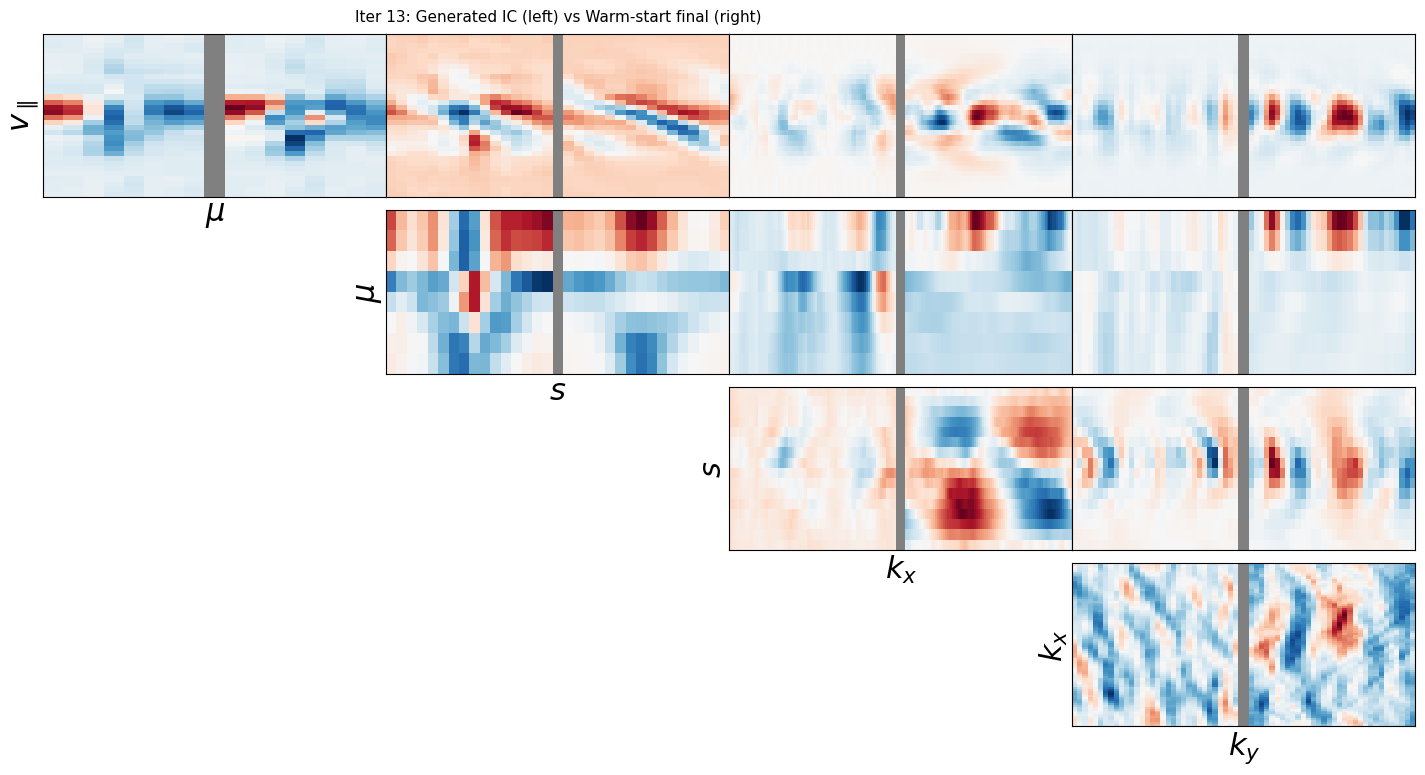

In [ ]:
from neugk.plot_utils import plot_nd

for it, res in warm_results.items():
    df_ic = torch.tensor(res["df_pred"], dtype=torch.float32)

    df_final = torch.tensor(to_model_space(res["log_warm"]["df_final"]), dtype=torch.float32)

    print(f"\nIteration {it}: IC vs final warm-start state")
    fig = plot_nd(df_ic, df_final, to_wandb=False)
    fig.suptitle(
        f"Iter {it}: Generated IC (left) vs Warm-start final (right)",
        fontsize=11,
        y=1.01,
    )

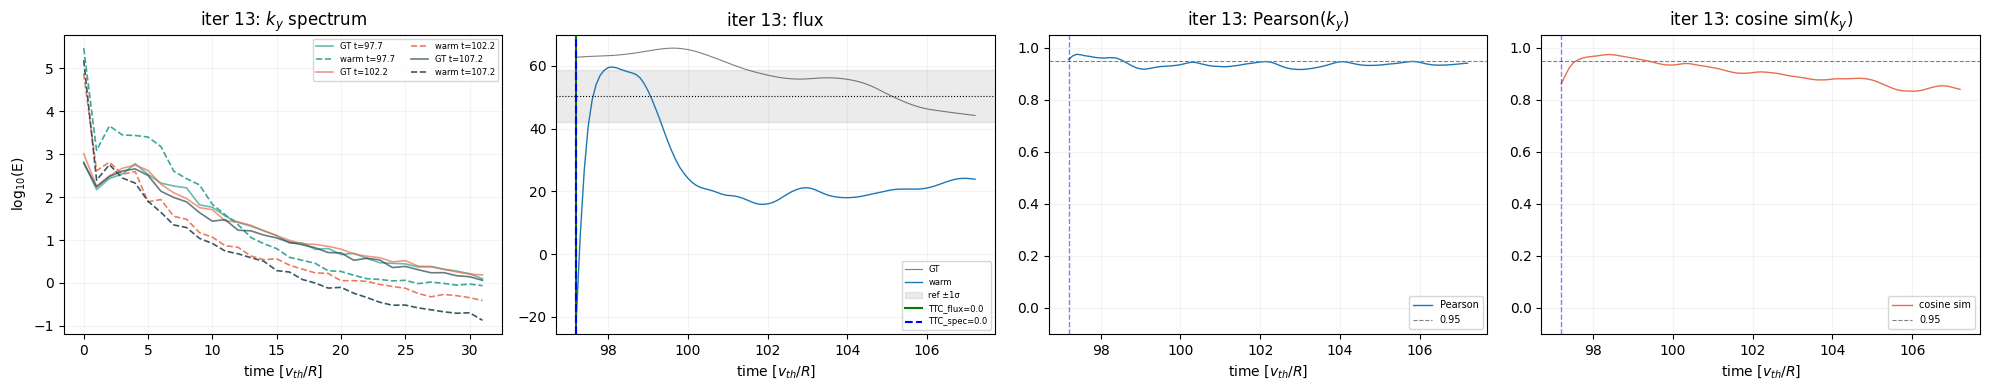

In [ ]:
n = len(warm_results)
fig, axes = plt.subplots(n, 4, figsize=(20, 4 * n), squeeze=False)
snap_colors = ["#2a9d8f", "#e76f51", "#264653"]

for row, (it, res) in enumerate(warm_results.items()):
    lg, lw, t = res["log_gt"], res["log_warm"], res["log_gt"]["time"]

    n_t = len(t)
    snap_idx = [min(5, n_t - 1), n_t // 2, n_t - 1]
    for j, si in enumerate(snap_idx):
        ky_gt = np.log10(np.maximum(lg["ky_spec"][si], 1e-30))
        ky_w = np.log10(np.maximum(lw["ky_spec"][si], 1e-30))
        lbl = f"t={float(t[si]):.1f}"
        axes[row, 0].plot(ky_gt, "-", color=snap_colors[j], lw=1.2, alpha=0.7, label=f"GT {lbl}")
        axes[row, 0].plot(ky_w, "--", color=snap_colors[j], lw=1.2, alpha=0.9, label=f"warm {lbl}")
    axes[row, 0].set(title=f"iter {it}: $k_y$ spectrum", xlabel="$k_y$ mode", ylabel="log$_{10}$(E)")
    axes[row, 0].legend(fontsize=6, ncol=2); axes[row, 0].grid(True, alpha=0.15)

    ref_mean, ref_std = load_reference_flux(GKW_RAW_DIR, it)
    axes[row, 1].plot(t, lg["eflux"], "k", lw=0.8, alpha=0.5, label="GT")
    axes[row, 1].plot(t, lw["eflux"], lw=1, label="warm")
    axes[row, 1].axhspan(ref_mean - ref_std, ref_mean + ref_std, color="k", alpha=0.08, label="ref ±1σ")
    axes[row, 1].axhline(ref_mean, color="k", ls=":", lw=0.8)
    if res["ttc_flux"] < np.inf:
        axes[row, 1].axvline(t[0] + res["ttc_flux"], color="green", ls="-", lw=1.5, label=f"TTC_flux={res['ttc_flux']:.1f}")
    if res["ttc_spec"] < np.inf:
        axes[row, 1].axvline(t[0] + res["ttc_spec"], color="blue", ls="--", lw=1.5, label=f"TTC_spec={res['ttc_spec']:.1f}")
    axes[row, 1].set_title(f"iter {it}: flux"); axes[row, 1].legend(fontsize=6); axes[row, 1].grid(True, alpha=0.15)

    n_compare = min(len(lw["ky_spec"]), len(lg["ky_spec"]))
    r_ts = [pearsonr(np.log10(np.maximum(lw["ky_spec"][i], 1e-30)),
                      np.log10(np.maximum(lg["ky_spec"][i], 1e-30)))[0]
            for i in range(n_compare)]
    axes[row, 2].plot(t[:n_compare], r_ts, lw=1, label="Pearson")
    axes[row, 2].axhline(0.95, color="gray", ls="--", lw=0.8, label="0.95")
    if res["ttc_spec"] < np.inf:
        axes[row, 2].axvline(t[0] + res["ttc_spec"], color="blue", ls="--", lw=1, alpha=0.5)
    axes[row, 2].set_title(f"iter {it}: Pearson($k_y$)"); axes[row, 2].set_ylim(-0.1, 1.05)
    axes[row, 2].legend(fontsize=7); axes[row, 2].grid(True, alpha=0.15)

    cos_ts = []
    for i in range(n_compare):
        ky_w = np.log10(np.maximum(lw["ky_spec"][i], 1e-30))
        ky_g = np.log10(np.maximum(lg["ky_spec"][i], 1e-30))
        nw = np.linalg.norm(ky_w)
        ng = np.linalg.norm(ky_g)
        cos_ts.append(np.dot(ky_w, ky_g) / (nw * ng + 1e-12))
    axes[row, 3].plot(t[:n_compare], cos_ts, lw=1, color="#e76f51", label="cosine sim")
    axes[row, 3].axhline(0.95, color="gray", ls="--", lw=0.8, label="0.95")
    if res["ttc_spec"] < np.inf:
        axes[row, 3].axvline(t[0] + res["ttc_spec"], color="blue", ls="--", lw=1, alpha=0.5)
    axes[row, 3].set_title(f"iter {it}: cosine sim($k_y$)"); axes[row, 3].set_ylim(-0.1, 1.05)
    axes[row, 3].legend(fontsize=7); axes[row, 3].grid(True, alpha=0.15)

for ax in axes[-1]:
    ax.set_xlabel(r"time $[v_{th}/R]$")
fig.tight_layout()

## 4. FID vs. Time-to-Convergence

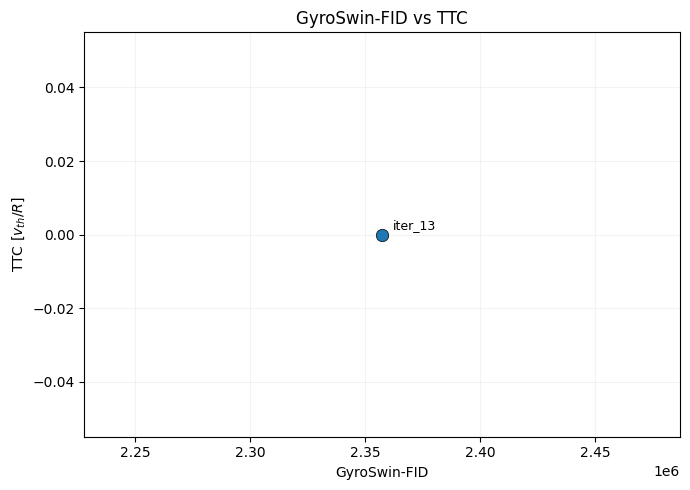

In [ ]:
fv, tv, lb = [], [], []
for it, res in warm_results.items():
    if np.isfinite(res["fid"]) and np.isfinite(res["ttc_flux"]):
        fv.append(res["fid"])
        tv.append(res["ttc_flux"])
        lb.append(f"iter_{it}")
fv, tv = np.array(fv), np.array(tv)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(fv, tv, s=80, zorder=3, edgecolors="k", linewidth=0.5)
for i, l in enumerate(lb):
    ax.annotate(l, (fv[i], tv[i]), textcoords="offset points", xytext=(8, 4), fontsize=9)
if len(fv) >= 3:
    co = np.polyfit(fv, tv, 1)
    xf = np.linspace(fv.min(), fv.max(), 100)
    ax.plot(xf, np.polyval(co, xf), "r--", lw=1.5)
    r, p = pearsonr(fv, tv)
    ax.text(
        0.05,
        0.95,
        f"r={r:.3f}, p={p:.3f}",
        transform=ax.transAxes,
        fontsize=12,
        va="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )
ax.set(xlabel=fid_label, ylabel=r"TTC $[v_{th}/R]$", title=f"{fid_label} vs TTC")
ax.grid(True, alpha=0.15)
fig.tight_layout()

In [ ]:
print(f"{'Iter':>8} {'FID':>10} {'TTC_flux':>10} {'TTC_spec':>10} {'RelErr':>10}")
print("-" * 54)
for it, r in warm_results.items():
    f = f"{r['fid']:.4f}" if np.isfinite(r["fid"]) else "N/A"
    tf = f"{r['ttc_flux']:.3f}" if np.isfinite(r["ttc_flux"]) else "inf"
    ts = f"{r['ttc_spec']:.3f}" if np.isfinite(r["ttc_spec"]) else "inf"

    Iter        FID   TTC_flux   TTC_spec     RelErr
------------------------------------------------------


## 5. Extended Correlation Analysis

In [ ]:
extended_metrics = {}
for it, res in warm_results.items():
    m = dict(fid=res["fid"], ttc=res["ttc_flux"])
    lg, lw = res["log_gt"], res["log_warm"]
    gm = np.mean(lg["eflux"][-80:])
    m["integral_flux_err"] = float(abs(lw["eflux"][0] - gm) / max(abs(gm), 1e-30))
    ky_lg = np.log10(np.maximum(np.mean(lg["ky_spec"][-80:], 0), 1e-30))
    ky_lw = np.log10(np.maximum(lw["ky_spec"][0], 1e-30))
    r_ky, _ = pearsonr(ky_lw, ky_lg) if len(ky_lg) > 1 else (0.0, 1.0)
    m["kyspec_pearson_init"] = float(r_ky)
    m["kyspec_rmse_init"] = float(np.sqrt(np.mean((ky_lw - ky_lg) ** 2)))
    kx_lg = np.log10(np.maximum(np.mean(lg["kx_spec"][-80:], 0), 1e-30))
    kx_lw = np.log10(np.maximum(lw["kx_spec"][0], 1e-30))
    m["kxspec_rmse_init"] = float(np.sqrt(np.mean((kx_lw - kx_lg) ** 2)))
    m["probe_flux_rmse"] = np.nan
    extended_metrics[it] = m
display(pd.DataFrame(extended_metrics).T.round(4))

,fid,ttc,integral_flux_err,kyspec_pearson_init,kyspec_rmse_init,kxspec_rmse_init,probe_flux_rmse
13,2.357426e+06,0.0,1.3822,0.96,1.1047,1.1926,NaN


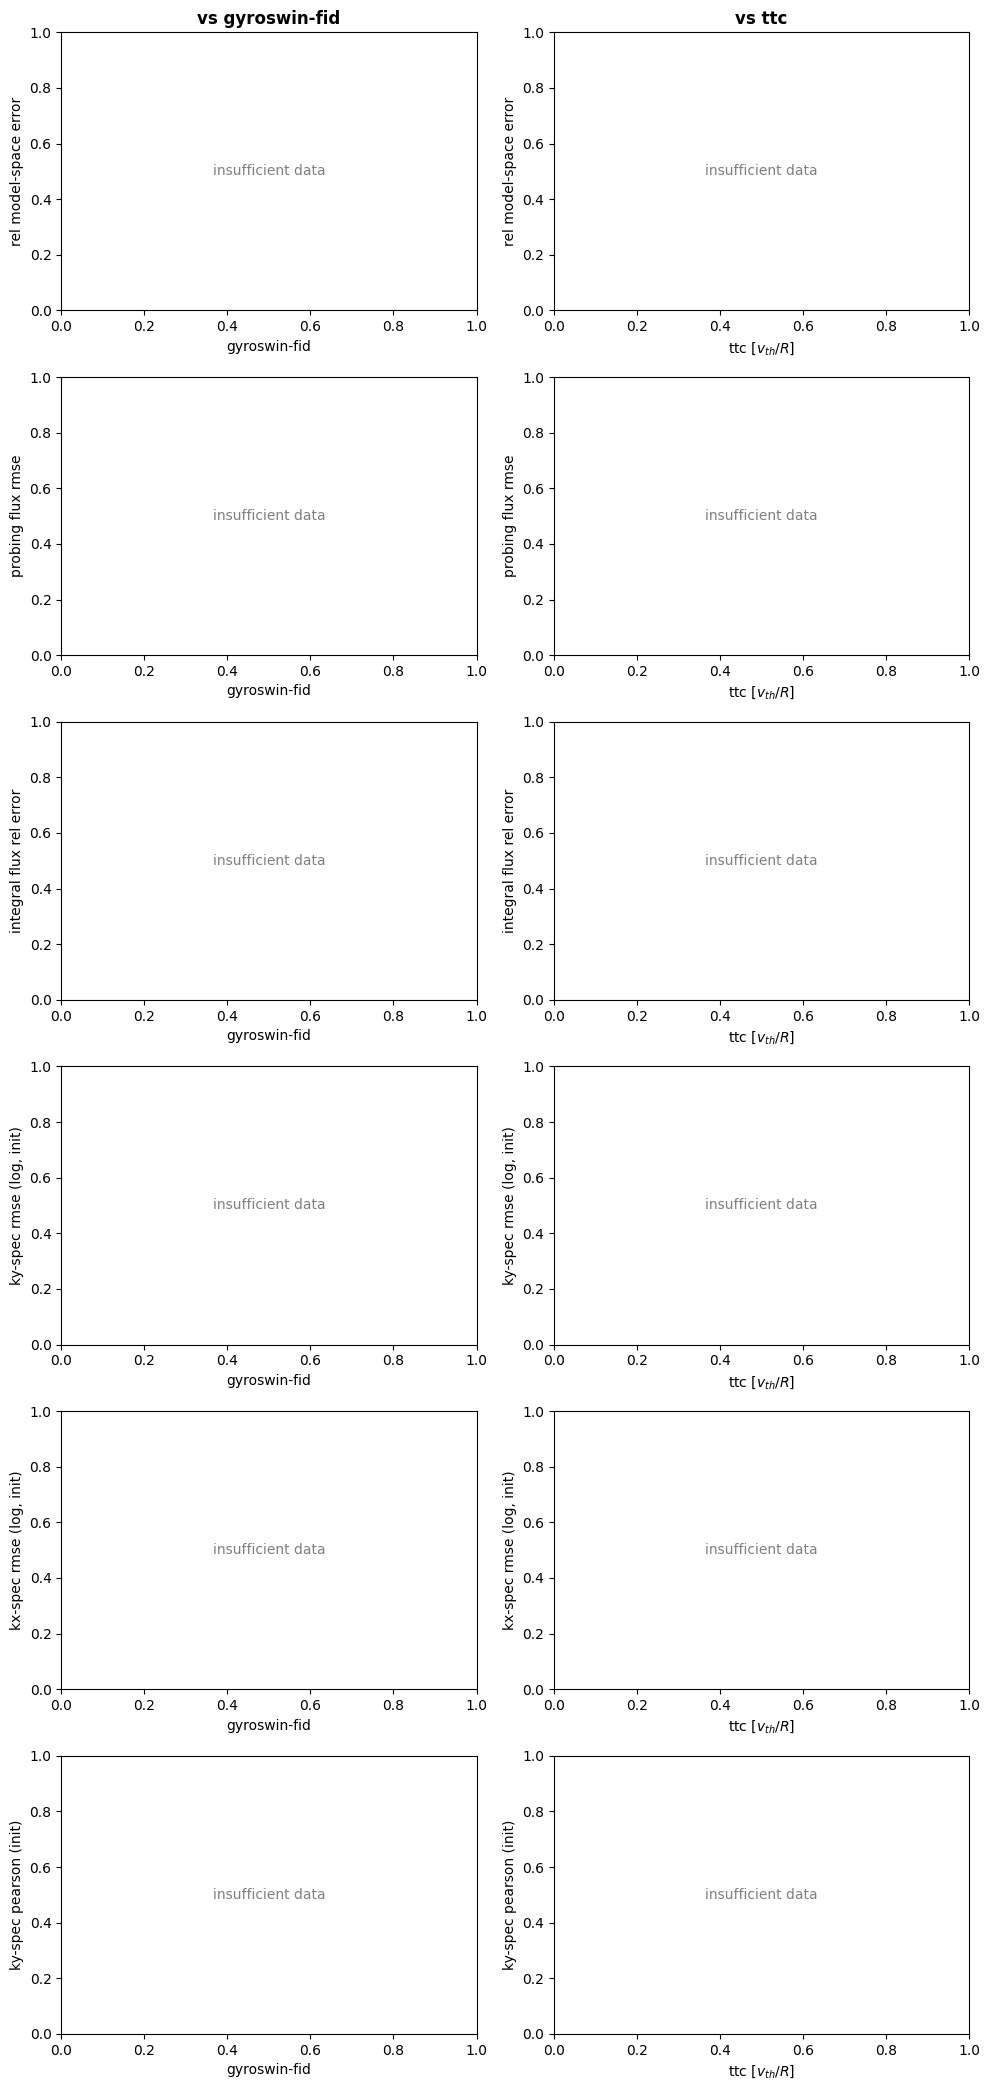

In [ ]:
_ = plot_correlation_grid(extended_metrics)